# PFAS Bond Dissociation Energy (BDE) Prediction using Machine Learning
This notebook demonstrates an end-to-end ML pipeline for predicting BDEs of PFAS compounds using benchmarked DFT calculations as ground the truth. 
The model uses molecular fingerprints and chemical environment features to generalize across different PFAS structures.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rdkit
from rdkit import Chem
import xgboost
from rdkit.Chem import AllChem
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GroupKFold
from rdkit import RDLogger
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.model_selection import cross_val_predict 
ROOT = Path.cwd()
# Disable all RDKit warnings
RDLogger.DisableLog('rdApp.*')# hydrogen warning pops up, due to [H] fragments

ImportError: cannot import name 'root_mean_squared_error' from 'sklearn.metrics' (C:\Users\mmarc\anaconda3\lib\site-packages\sklearn\metrics\__init__.py)

### Reproducibility Note

Results may vary slightly depending on package versions due to numerical precision differences in underlying linear algebra libraries and algorithm implementations. The relative performance and rankings of models remain consistent.

In [ ]:
print("sklearn:", sklearn.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("xgb:", xgboost.__version__)

In [3]:
# helper functions for fingerprints and data mapping
def smiles_to_fp(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(nBits)
    return np.array(
        AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    )

def build_fp_block(df, col):
    return np.vstack(df[col].apply(smiles_to_fp).values)
# Build SEPARATE XYZ mappings for each dataset
# def map_smiles_to_xyz(smiles_series, xyz_map, column_name):
#     result = []
#     missing = []
    
#     for smi in smiles_series:
#         if smi in xyz_map.index:
#             result.append(xyz_map[smi])
#         else:
#             result.append(None)
#             missing.append(smi)
    
#     if missing:
#         print(f"Warning: {len(missing)} SMILES in '{column_name}' not found in XYZ map")
#         print(f"First 5 missing: {missing[:5]}")
    
#     return pd.Series(result, index=smiles_series.index)

In [4]:
# block to load data in
# Load anion (deprotonated) data
#df_QM_full_anion = pd.read_csv("Data/Anion_table_full.csv")
df_anion = pd.read_csv("../Data/Enthalpy_Anion_BDE_table.csv")
df_anion = df_anion.dropna()
df_anion = df_anion.drop(columns=['BDEhet_wB97X-V', 'Bond_Index'])
df_anion['deprotonation'] = True
df_anion['solvent'] = 'water'

# Load neutral (protonated) data
#df_QM_full_neutral = pd.read_csv("Data/Neutral_table_full.csv")
df_neutral = pd.read_csv("../Data/Enthalpy_Neutral_BDE_table.csv")
df_neutral = df_neutral.dropna()
df_neutral = df_neutral.drop(columns=['Bond_Index'])
df_neutral['deprotonation'] = False
df_neutral['solvent'] = 'gas'

# Build XYZ mapping for ANION data
#xyz_lists_anion = df_QM_full_anion.groupby('Canonical_SMILES')['XYZ'].agg(list)
# dupe_smiles_anion = xyz_lists_anion[xyz_lists_anion.apply(len) > 1]
# if len(dupe_smiles_anion) > 0:
#     raise ValueError(
#         "Anion dataset has duplicate SMILES. "
#         f"Examples: {dupe_smiles_anion}"
#     )
# xyz_map_anion = xyz_lists_anion.apply(lambda x: x[0])

# Build XYZ mapping for NEUTRAL data
#xyz_lists_neutral = df_QM_full_neutral.groupby('Canonical_SMILES')['XYZ'].agg(list)
# dupe_smiles_neutral = xyz_lists_neutral[xyz_lists_neutral.apply(len) > 1]
# if len(dupe_smiles_neutral) > 0:
#     print(
#         "Neutral dataset has duplicate SMILES. "
#         f"Examples: {dupe_smiles_neutral.index.tolist()[:10]}"
#     )
#     df_QM_full_neutral = df_QM_full_neutral.drop_duplicates(subset='Canonical_SMILES', keep='first')
# xyz_map_neutral = xyz_lists_neutral.apply(lambda x: x[0])

# # Map XYZ to ANION dataframe (use anion XYZ map)
# df_anion['Parent_SMILES_XYZ'] = map_smiles_to_xyz(df_anion['Parent_SMILES'], xyz_map_anion, 'Parent_SMILES')
# df_anion['Frag1_SMILES_XYZ'] = map_smiles_to_xyz(df_anion['Frag1_SMILES'], xyz_map_anion, 'Frag1_SMILES')
# df_anion['Frag2_SMILES_XYZ'] = map_smiles_to_xyz(df_anion['Frag2_SMILES'], xyz_map_anion, 'Frag2_SMILES')

# # Map XYZ to NEUTRAL dataframe (use neutral XYZ map)
# df_neutral['Parent_SMILES_XYZ'] = map_smiles_to_xyz(df_neutral['Parent_SMILES'], xyz_map_neutral, 'Parent_SMILES')
# df_neutral['Frag1_SMILES_XYZ'] = map_smiles_to_xyz(df_neutral['Frag1_SMILES'], xyz_map_neutral, 'Frag1_SMILES')
# df_neutral['Frag2_SMILES_XYZ'] = map_smiles_to_xyz(df_neutral['Frag2_SMILES'], xyz_map_neutral, 'Frag2_SMILES')

# NOW combine the datasets
df = pd.concat([df_anion, df_neutral], ignore_index=True)
anion_dupes = df_anion.duplicated()
if anion_dupes.sum() > 0:
    print(f"   ⚠️  Found {anion_dupes.sum()} duplicate rows")
    print(f"   Example duplicate rows:")
    print(df_anion[anion_dupes].head())
else:
    print("   ✓ No duplicate rows found")
neutral_dupes = df_neutral.duplicated()
if neutral_dupes.sum() > 0:
    print(f"   ⚠️  Found {neutral_dupes.sum()} duplicate rows")
    print(f"   Example duplicate rows:")
    print(df_neutral[neutral_dupes].head())
else:
    print("   ✓ No duplicate rows found")

print("\n" + "="*80)
print(f"COMBINED DATASET SUMMARY")
print(f"Total bonds: {len(df)}")
print(f"  - Deprotonated (water): {len(df[df['deprotonation']==True])}")
print(f"  - Protonated (gas): {len(df[df['deprotonation']==False])}")
print(f"\nUnique molecules: {len(df['Parent_SMILES'].unique())}")
print(f"  - Deprotonated: {len(df[df['deprotonation']==True]['Parent_SMILES'].unique())}")
print(f"  - Protonated: {len(df[df['deprotonation']==False]['Parent_SMILES'].unique())}")
print(f"\nBDE range: {df['BDE_wB97X-V'].min():.2f} - {df['BDE_wB97X-V'].max():.2f} kcal/mol")
print(f"BDE std: {df['BDE_wB97X-V'].std():.2f} kcal/mol")
print(f"{'='*60}\n")

df.head()

   ✓ No duplicate rows found
   ✓ No duplicate rows found

COMBINED DATASET SUMMARY
Total bonds: 701
  - Deprotonated (water): 283
  - Protonated (gas): 418

Unique molecules: 81
  - Deprotonated: 32
  - Protonated: 49

BDE range: 62.13 - 130.75 kcal/mol
BDE std: 15.08 kcal/mol



,Parent_SMILES,Frag1_SMILES,Frag2_SMILES,BDE_wB97X-V,deprotonation,solvent
0,[H]C([H])([H])S(=O)(=O)[O-],[H][C]([H])[H],O=[S](=O)[O-],77.996727,True,water
1,[H]C([H])([H])S(=O)(=O)[O-],[H][C]([H])S(=O)(=O)[O-],[H],105.602360,True,water
2,[H]C([H])([H])C(=O)[O-],[H][C]([H])[H],O=[C][O-],85.924202,True,water
3,[H]C([H])([H])C(=O)[O-],[H][C]([H])C(=O)[O-],[H],99.409015,True,water
4,[H]C([H])(F)S(=O)(=O)[O-],[H][C]([H])S(=O)(=O)[O-],[F],113.520421,True,water


In [7]:
#df

### Checking correlation and ablation between features.
This block shows that the deprotonation are unnecessary. In early stages of PFAS database building this will also show that the solvent is unnecessary due to protonated PFAS only being modeled in gas phases and deprotonated in implicit water. However, the database will be expanding greatly, if it is not already, so this feature will stay in. 
Surprisingly, even with fingerprinting both fragments in the bond it is still necessary to fingerprint the parent PFAS as well for ridge regression. This is most likely due to the fingerprints unable to caprute the originaly bonding environment in the radical fragments that is essestial for prediction. 

Ridge regression and random forest was used for the ablation study. The test and trainig sets are split by 5 k-fold with parent PFAS. 

PART 1: CORRELATION ANALYSIS

Correlation of categorical features with BDE:
  deprotonation       : r = -0.096
  solvent_water       : r = -0.096

Mean BDE by condition:
                             mean        std  count
deprotonation solvent                              
False         gas      103.633480  14.928504    418
True          water    100.674676  15.166401    283


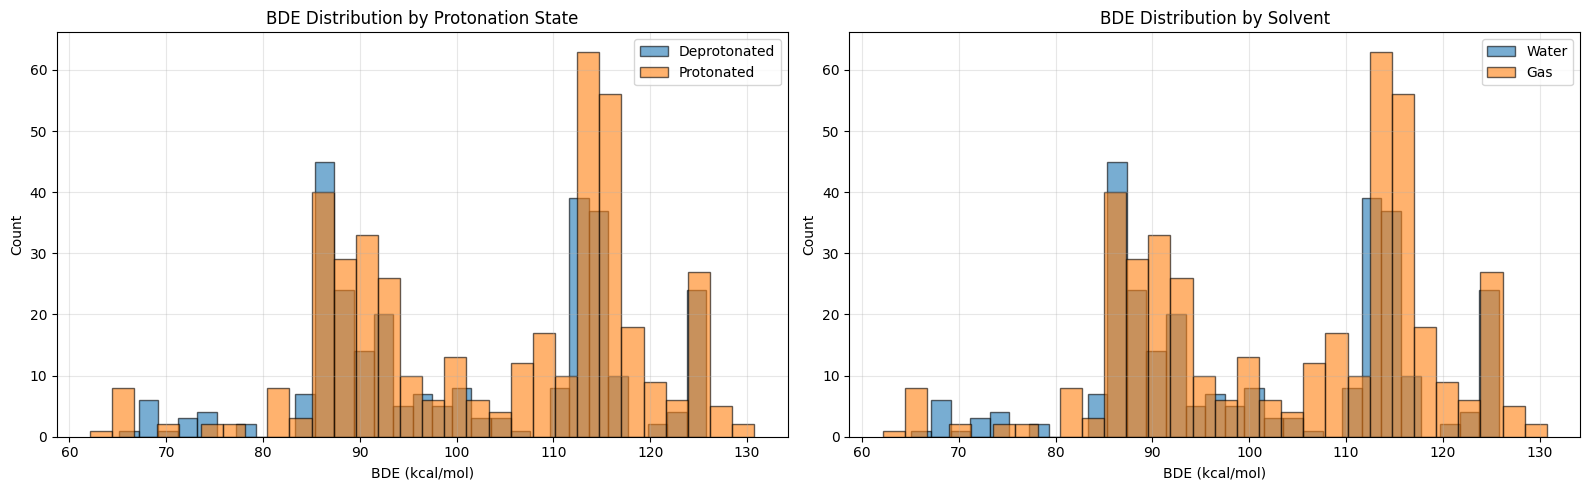


Feature overlap check:
  Deprotonated AND water: 283
  Protonated AND gas: 418
  Deprotonated AND gas: 0
  Protonated AND water: 0

PART 2: ABLATION STUDY
Testing which features actually improve model performance...


Ridge Results:
------------------------------------------------------------
Configuration                  MAE (kcal/mol)      
------------------------------------------------------------
All features                   1.857 ± 0.180
No parent FP                   2.161 ± 0.213
No flags (FP only)             1.852 ± 0.176
Fragments + flags              2.161 ± 0.213
Fragments only                 2.168 ± 0.225

✓ Best for Ridge: No flags (FP only)
  MAE: 1.852 ± 0.176

Random Forest Results:
------------------------------------------------------------
Configuration                  MAE (kcal/mol)      
------------------------------------------------------------
All features                   1.533 ± 0.230
No parent FP                   1.511 ± 0.248
No flags (FP only)  

In [5]:
# Feature Analysis - Correlation and Ablation
print("="*60)
print("PART 1: CORRELATION ANALYSIS")
print("="*60)

y = df['BDE_wB97X-V'].values

# Create a feature dataframe with interpretable names
feature_df = pd.DataFrame({
    'BDE': y,
    'deprotonation': df['deprotonation'].astype(int),
    'solvent_water': (df['solvent'] == 'water').astype(int),
})

# Calculate correlations
corr_with_target = feature_df.corr()['BDE'].drop('BDE').sort_values(ascending=False)
print("\nCorrelation of categorical features with BDE:")
for feat, corr_val in corr_with_target.items():
    print(f"  {feat:20s}: r = {corr_val:+.3f}")

# Calculate mean BDE by condition
conditions = df.groupby(['deprotonation', 'solvent'])['BDE_wB97X-V'].agg(['mean', 'std', 'count'])
print(f"\nMean BDE by condition:")
print(conditions)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: BDE distribution by deprotonation state
axes[0].hist(df[df['deprotonation']==True]['BDE_wB97X-V'], 
             bins=30, alpha=0.6, label='Deprotonated', edgecolor='black')
axes[0].hist(df[df['deprotonation']==False]['BDE_wB97X-V'], 
             bins=30, alpha=0.6, label='Protonated', edgecolor='black')
axes[0].set_xlabel('BDE (kcal/mol)')
axes[0].set_ylabel('Count')
axes[0].set_title('BDE Distribution by Protonation State')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: BDE distribution by solvent
axes[1].hist(df[df['solvent']=='water']['BDE_wB97X-V'], 
             bins=30, alpha=0.6, label='Water', edgecolor='black')
axes[1].hist(df[df['solvent']=='gas']['BDE_wB97X-V'], 
             bins=30, alpha=0.6, label='Gas', edgecolor='black')
axes[1].set_xlabel('BDE (kcal/mol)')
axes[1].set_ylabel('Count')
axes[1].set_title('BDE Distribution by Solvent')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../Data/Figures/bde_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Check if deprotonation and solvent are perfectly correlated
print(f"\nFeature overlap check:")
print(f"  Deprotonated AND water: {((df['deprotonation']==True) & (df['solvent']=='water')).sum()}")
print(f"  Protonated AND gas: {((df['deprotonation']==False) & (df['solvent']=='gas')).sum()}")
print(f"  Deprotonated AND gas: {((df['deprotonation']==True) & (df['solvent']=='gas')).sum()}")
print(f"  Protonated AND water: {((df['deprotonation']==False) & (df['solvent']=='water')).sum()}")


print("\n" + "="*60)
print("PART 2: ABLATION STUDY")
print("="*60)
print("Testing which features actually improve model performance...")
print()

# Build feature sets (assuming these were built earlier in your code)
# If not, you'll need to add the build_fp_block function calls here
X_parent = build_fp_block(df, 'Parent_SMILES')
X_frag1 = build_fp_block(df, 'Frag1_SMILES')
X_frag2 = build_fp_block(df, 'Frag2_SMILES')

# Encode categorical features
enc = OneHotEncoder(sparse_output=False)
X_solvent = enc.fit_transform(df[['solvent']])
X_deprotonation = df['deprotonation'].values.reshape(-1, 1).astype(float)

# Combine categorical features into "flags"
X_flags = np.hstack([X_solvent, X_deprotonation])

# All fingerprints
X_fp = np.hstack([X_parent, X_frag1, X_frag2])

# Full feature set
X = np.hstack([X_parent, X_frag1, X_frag2, X_flags])

# Define feature configurations for ablation
feature_configs = {
    'All features': X,
    'No parent FP': np.hstack([X_frag1, X_frag2, X_flags]),
    'No flags (FP only)': X_fp,
    'Fragments + flags': np.hstack([X_frag1, X_frag2, X_flags]),
    'Fragments only': np.hstack([X_frag1, X_frag2]),
}

groups = df['Parent_SMILES'].values
gkf = GroupKFold(n_splits=5)

# Test with multiple model types
models_to_test = {
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
}

for model_name, model in models_to_test.items():
    print(f"\n{model_name} Results:")
    print("-" * 60)
    print(f"{'Configuration':<30s} {'MAE (kcal/mol)':<20s}")
    print("-" * 60)
    
    results = {}
    for config_name, X_test in feature_configs.items():
        scores = cross_val_score(
            model, X_test, y,
            cv=gkf,
            groups=groups,
            scoring='neg_mean_absolute_error',
            n_jobs=-1
        )
        mae = -scores.mean()
        std = scores.std()
        results[config_name] = {'MAE': mae, 'STD': std}
        print(f"{config_name:<30s} {mae:.3f} ± {std:.3f}")
    
    # Identify best config for this model
    best_config = min(results.items(), key=lambda x: x[1]['MAE'])
    print(f"\n✓ Best for {model_name}: {best_config[0]}")
    print(f"  MAE: {best_config[1]['MAE']:.3f} ± {best_config[1]['STD']:.3f}")

print("\n" + "="*60)
print("ABLATION STUDY COMPLETE")
print("="*60)

### Testing across various models with 2 different feature sets
Feature set one will have Fingerprints done on Paretn, Fragment A, Fragment B, and solvation 
Feature set two will have fingerprints on fragment A, fragment B, and solvation. 

The test/train method will be a 5-k fold split by parent PFAS this is to prevent model leakage from traingin on specific parent PFAS.

COMPREHENSIVE MODEL COMPARISON

Dataset: 701 bonds from 81 unique molecules
BDE range: 62.13 - 130.75 kcal/mol (σ = 15.07)

Feature configurations:
  Full Features: 6146 features
  Fragments Only: 4098 features

Cross-validation: 5-fold GroupKFold (prevents molecule leakage)

FEATURE SET: Full Features

  Baseline (Mean)      → MAE: 13.569 ± 0.213 | R²: -0.003 | 0.0s
  Ridge                → MAE: 1.855 ± 0.178 | R²: 0.938 | 0.1s
  Lasso                → MAE: 5.867 ± 0.327 | R²: 0.656 | 0.1s
  ElasticNet           → MAE: 7.328 ± 0.385 | R²: 0.594 | 0.1s
  Random Forest        → MAE: 1.642 ± 0.249 | R²: 0.946 | 3.9s
  Gradient Boosting    → MAE: 1.609 ± 0.196 | R²: 0.954 | 3.4s
  XGBoost              → MAE: 1.582 ± 0.163 | R²: 0.950 | 2.0s
  Neural Network       → MAE: 4.440 ± 0.558 | R²: 0.670 | 115.2s

FEATURE SET: Fragments Only

  Baseline (Mean)      → MAE: 13.569 ± 0.213 | R²: -0.003 | 0.0s
  Ridge                → MAE: 2.161 ± 0.215 | R²: 0.935 | 0.1s
  Lasso                → MAE:

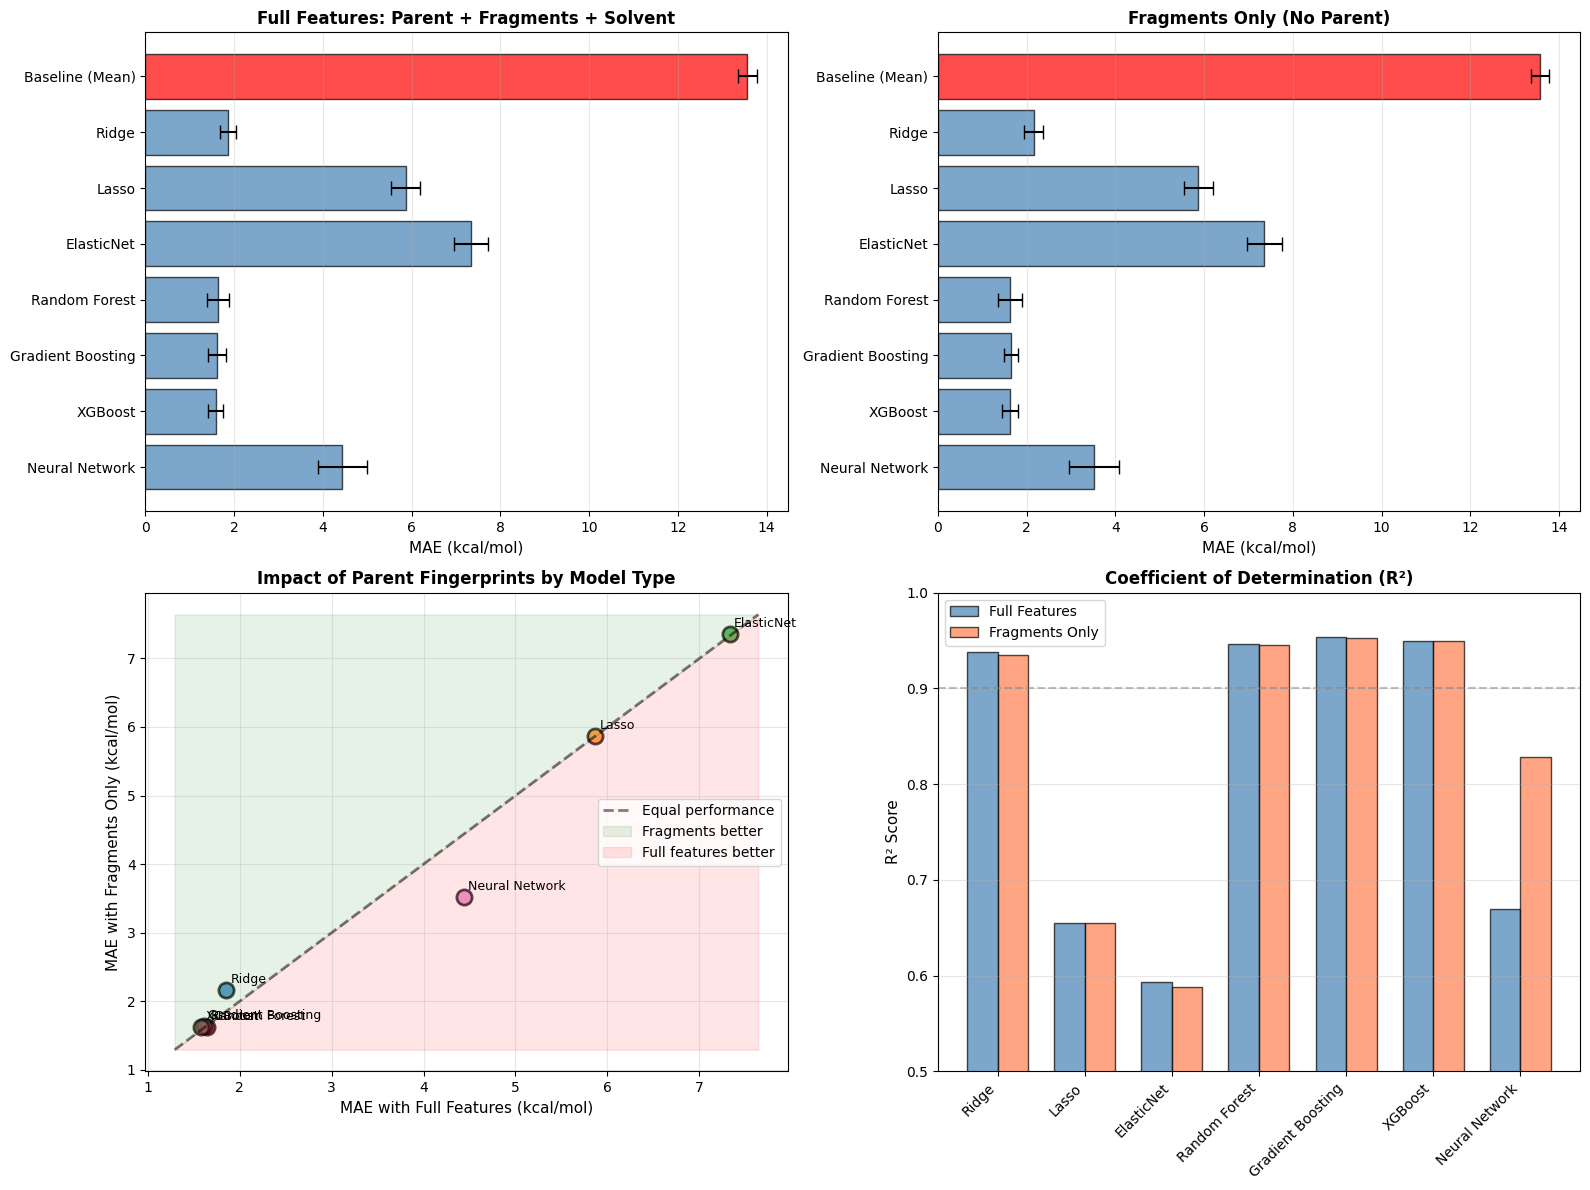


✓ Visualization saved as 'Data/Figures/model_comparison.png'



In [6]:

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.dummy import DummyRegressor
import time

print("="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

# ============================================================================
# FEATURE SET DEFINITION
# ============================================================================

y = df['BDE_wB97X-V'].values

# Generate fingerprints
X_parent = build_fp_block(df, 'Parent_SMILES')
X_frag1  = build_fp_block(df, 'Frag1_SMILES')
X_frag2  = build_fp_block(df, 'Frag2_SMILES')

# Encode solvent (kept for future database expansion with varied conditions)
enc = OneHotEncoder(sparse_output=False)
X_solvent = enc.fit_transform(df[['solvent']])

# Define feature sets
feature_sets = {
    'Full Features': np.hstack([X_parent, X_frag1, X_frag2, X_solvent]),
    'Fragments Only': np.hstack([X_frag1, X_frag2, X_solvent])
}

print(f"\nDataset: {len(df)} bonds from {df['Parent_SMILES'].nunique()} unique molecules")
print(f"BDE range: {y.min():.2f} - {y.max():.2f} kcal/mol (σ = {y.std():.2f})")
print(f"\nFeature configurations:")
for name, X_set in feature_sets.items():
    print(f"  {name}: {X_set.shape[1]} features")

# Cross-validation setup
groups = df['Parent_SMILES']
gkf = GroupKFold(n_splits=5)
print(f"\nCross-validation: 5-fold GroupKFold (prevents molecule leakage)")

# ============================================================================
# MODEL DEFINITIONS
# ============================================================================

models = {
    'Baseline (Mean)': DummyRegressor(strategy='mean'),
    'Ridge': Ridge(alpha=1), # moderate penalty
    'Lasso': Lasso(alpha=1, max_iter=5000), # could decrease alpha and maybe improve Lasso
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, 
        max_depth=15, 
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    'Neural Network': MLPRegressor(
         hidden_layer_sizes=(512, 256, 128),  # Three layers with gradual reduction
        activation='relu',
        alpha=0.001,                         # Lighter regularization to start
        max_iter=2000,                       # More iterations for deeper network
        learning_rate_init=0.001,
        solver='adam',                       # Adam usually works well
        batch_size='auto',                   # Will be min(200, n_samples)
        random_state=42,
        validation_fraction=0.2,
        n_iter_no_change=30,                 # More patience for deeper network
        early_stopping=True,
        verbose=False
    )
}

# ============================================================================
# TRAINING AND EVALUATION
# ============================================================================

all_results = {}

for feature_name, X in feature_sets.items():
    print(f"\n{'='*80}")
    print(f"FEATURE SET: {feature_name}")
    print(f"{'='*80}\n")
    
    results = {}
    
    for model_name, model in models.items():
        print(f"  {model_name:<20s}", end=' ')
        start_time = time.time()
        
        maes = []
        rmses = []
        r2s = []
        
        for train_idx, test_idx in gkf.split(X, y, groups):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            maes.append(mean_absolute_error(y_test, y_pred))
            rmses.append(root_mean_squared_error(y_test, y_pred))
            r2s.append(r2_score(y_test, y_pred))
        
        train_time = time.time() - start_time
        
        results[model_name] = {
            'MAE_mean': np.mean(maes),
            'MAE_std': np.std(maes),
            'RMSE_mean': np.mean(rmses),
            'RMSE_std': np.std(rmses),
            'R2_mean': np.mean(r2s),
            'R2_std': np.std(r2s),
            'Time': train_time
        }
        
        print(f"→ MAE: {np.mean(maes):.3f} ± {np.std(maes):.3f} | R²: {np.mean(r2s):.3f} | {train_time:.1f}s")
    
    all_results[feature_name] = results

# ============================================================================
# RESULTS SUMMARY
# ============================================================================

print(f"\n{'='*80}")
print("RESULTS SUMMARY")
print(f"{'='*80}\n")

for feature_name, results in all_results.items():
    print(f"\n{feature_name}")
    print("-" * 80)
    print(f"{'Model':<20} {'MAE (kcal/mol)':<25} {'RMSE (kcal/mol)':<25} {'R²':<15}")
    print("-" * 80)
    
    sorted_models = sorted(results.items(), key=lambda x: x[1]['MAE_mean'])
    for model_name, res in sorted_models:
        mae_str = f"{res['MAE_mean']:.3f} ± {res['MAE_std']:.3f}"
        rmse_str = f"{res['RMSE_mean']:.3f} ± {res['RMSE_std']:.3f}"
        r2_str = f"{res['R2_mean']:.3f} ± {res['R2_std']:.3f}"
        
        # Highlight best model
        marker = "🏆" if model_name == sorted_models[0][0] else "  "
        print(f"{marker} {model_name:<18} {mae_str:<25} {rmse_str:<25} {r2_str:<15}")

# ============================================================================
# BEST MODEL IDENTIFICATION
# ============================================================================

print(f"\n{'='*80}")
print("BEST MODEL SELECTION")
print(f"{'='*80}")

best_overall = None
best_mae = float('inf')

for feature_name, results in all_results.items():
    for model_name, res in results.items():
        if model_name != 'Baseline (Mean)' and res['MAE_mean'] < best_mae:
            best_mae = res['MAE_mean']
            best_overall = (feature_name, model_name, res)

print(f"\n🏆 Best Overall Performance:")
print(f"   Model:       {best_overall[1]}")
print(f"   Features:    {best_overall[0]}")
print(f"   MAE:         {best_overall[2]['MAE_mean']:.3f} ± {best_overall[2]['MAE_std']:.3f} kcal/mol")
print(f"   RMSE:        {best_overall[2]['RMSE_mean']:.3f} ± {best_overall[2]['RMSE_std']:.3f} kcal/mol")
print(f"   R²:          {best_overall[2]['R2_mean']:.3f} ± {best_overall[2]['R2_std']:.3f}")

print(f"\n📊 Performance Context:")
print(f"   DFT accuracy for BDEs:     ~2-5 kcal/mol")
print(f"   Chemical accuracy goal:    ~1 kcal/mol")
baseline_mae = all_results['Full Features']['Baseline (Mean)']['MAE_mean']
improvement = ((baseline_mae - best_mae) / baseline_mae) * 100
print(f"   Improvement over baseline: {improvement:.1f}%")
print("="*80)

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Get model names (excluding baseline for some plots)
model_names_all = [m for m in models.keys()]
model_names = [m for m in models.keys() if m != 'Baseline (Mean)']

# Plot 1: MAE comparison - Full Features
results = all_results['Full Features']
maes = [results[m]['MAE_mean'] for m in model_names_all]
mae_stds = [results[m]['MAE_std'] for m in model_names_all]

colors = ['red' if m == 'Baseline (Mean)' else 'steelblue' for m in model_names_all]
axes[0, 0].barh(model_names_all, maes, xerr=mae_stds, capsize=5, 
                edgecolor='black', alpha=0.7, color=colors)
axes[0, 0].set_xlabel('MAE (kcal/mol)', fontsize=11)
axes[0, 0].set_title('Full Features: Parent + Fragments + Solvent', fontsize=12, fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: MAE comparison - Fragments Only
results = all_results['Fragments Only']
maes = [results[m]['MAE_mean'] for m in model_names_all]
mae_stds = [results[m]['MAE_std'] for m in model_names_all]

axes[0, 1].barh(model_names_all, maes, xerr=mae_stds, capsize=5,
                edgecolor='black', alpha=0.7, color=colors)
axes[0, 1].set_xlabel('MAE (kcal/mol)', fontsize=11)
axes[0, 1].set_title('Fragments Only (No Parent)', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

# Plot 3: Feature set comparison scatter
for model_name in model_names:
    full_mae = all_results['Full Features'][model_name]['MAE_mean']
    frag_mae = all_results['Fragments Only'][model_name]['MAE_mean']
    axes[1, 0].scatter(full_mae, frag_mae, s=120, alpha=0.7, edgecolor='black', linewidths=2)
    axes[1, 0].annotate(model_name, (full_mae, frag_mae), fontsize=9, 
                       ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

# Add diagonal reference line
lims = [
    min(axes[1, 0].get_xlim()[0], axes[1, 0].get_ylim()[0]),
    max(axes[1, 0].get_xlim()[1], axes[1, 0].get_ylim()[1])
]
axes[1, 0].plot(lims, lims, 'k--', alpha=0.5, linewidth=2, label='Equal performance')
axes[1, 0].fill_between(lims, lims, [lims[1]]*2, alpha=0.1, color='green', 
                        label='Fragments better')
axes[1, 0].fill_between(lims, [lims[0]]*2, lims, alpha=0.1, color='red',
                        label='Full features better')
axes[1, 0].set_xlabel('MAE with Full Features (kcal/mol)', fontsize=11)
axes[1, 0].set_ylabel('MAE with Fragments Only (kcal/mol)', fontsize=11)
axes[1, 0].set_title('Impact of Parent Fingerprints by Model Type', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: R² comparison
r2s_full = [all_results['Full Features'][m]['R2_mean'] for m in model_names]
r2s_frag = [all_results['Fragments Only'][m]['R2_mean'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

axes[1, 1].bar(x - width/2, r2s_full, width, label='Full Features', 
              alpha=0.7, edgecolor='black', color='steelblue')
axes[1, 1].bar(x + width/2, r2s_frag, width, label='Fragments Only',
              alpha=0.7, edgecolor='black', color='coral')
axes[1, 1].set_ylabel('R² Score', fontsize=11)
axes[1, 1].set_title('Coefficient of Determination (R²)', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(model_names, rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_ylim([0.5, 1.0])
axes[1, 1].axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='R²=0.9')

plt.tight_layout()
plt.savefig('../Data/Figures/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'Data/Figures/model_comparison.png'\n")

## Model Performance Analysis

This section explains each model's approach to predicting bond dissociation energies (BDEs) and why certain architectures outperform others for our dataset.

---

### **Baseline (Mean Prediction)**
**Purpose:** Establishes a performance floor by predicting the average BDE for all bonds.


This represents the error from simply guessing the mean BDE regardless of molecular structure. Any viable model must substantially outperform this baseline, demonstrating that molecular features contain predictive information.

---

### **Ridge Regression**
**Approach:** Linear model with L2 regularization, treating each molecular fingerprint bit as an independent predictor.


**Interpretation:** Ridge achieves strong performance, validating this feature engineering approach. The model requires parent molecule fingerprints because it cannot learn interactions between fragment features, it needs explicit bond environment information from parent due to treating each fingerprint independently. The rapid training time and interpretable coefficients make Ridge an excellent new baseline for comparison.

---

### **Lasso Regression**
**Approach:** Linear model with L1 regularization, which drives feature coefficients to exactly zero for aggressive feature selection.


**Interpretation:** Lasso significantly underperforms because molecular fingerprints are sparse (most bits are zero for any given molecule). The L1 penalty interprets infrequent fingerprint bits as uninformative and eliminates them, discarding critical structural information. Performance is nearly identical with or without parent fingerprints, indicating Lasso has already eliminated most molecular context. **Conclusion:** L1 regularization is inappropriate for sparse molecular fingerprints.

---

### **ElasticNet**
**Approach:** Combines L1 and L2 regularization (50/50 mix) to balance feature selection with coefficient shrinkage.


**Interpretation:** The L1 component continues to aggressively eliminate features, resulting in performance between Lasso and Ridge but closer to Lasso. Even the 50% L2 contribution cannot compensate for information loss from L1 feature elimination. Like Lasso, performance is insensitive to parent fingerprints because most molecular information has been discarded.

---

### **Random Forest**
**Approach:** Ensemble of 100 decision trees trained independently on bootstrapped samples, capturing non-linear feature interactions.

**Interpretation:** Random Forest outperforms Ridge by learning feature interactions through decision trees. Unlike linear models, RF can discover patterns like "IF fragment A contains substructure X AND fragment B contains substructure Y, THEN BDE ≈ Z." This is critical for BDE prediction, as bond strength depends on the combined electronic environment of both fragments.
Notably, RF performs nearly identically with or without parent fingerprints (Full: 1.642 vs Fragments: 1.630 MAE), suggesting it reconstructs bond environment information by learning fragment interaction patterns. However, RF exhibits higher variance (±0.249) than Ridge due to sensitivity to bootstrap sampling with our limited dataset size.

---

### **Gradient Boosting**
**Approach:** Builds decision trees sequentially, where each new tree focuses on correcting errors from previous trees.

**Interpretation:** Gradient Boosting improves upon Random Forest through adaptive learning—later trees specialize in difficult predictions where earlier trees struggled. This sequential approach yields slightly better accuracy and lower variance (±0.196 vs ±0.249) compared to RF. The model is included as a reference implementation of boosting before comparing to the optimized XGBoost variant.

---

### **XGBoost**
**Approach:** Optimized gradient boosting implementation with regularization, parallel processing, and efficient handling of sparse features.


**Interpretation:** XGBoost achieves the best overall performance with the lowest MAE (1.582 kcal/mol) and tightest variance (±0.163), while training faster than Gradient Boosting. The model benefits from:
- **Regularization:** Prevents individual trees from overfitting
- **Sparse feature optimization:** Efficiently handles fingerprint vectors that are 95%+ zeros  
- **Sequential learning:** Each tree corrects predecessor mistakes, focusing effort on difficult predictions


**Recommendation:** XGBoost is the production model choice given its optimal performance-speed-stability balance.

---

### **Neural Network**
**Approach:** Single-layer feedforward network (32 neurons) with strong regularization, designed for small dataset constraints.


**Interpretation:** Neural networks face fundamental challenges with our dataset size. The original three-layer architecture created a parameter-to-data ratio far exceeding recommended guidelines (1:10 to 1:100). A simplified single-layer architecture with stronger regularization improves performance but still cannot match tree-based models. This demonstrates that even with appropriate architectural choices, neural networks require substantially more data than our dataset provides.

The challenges manifest as:
1. **Insufficient data:** Tree models use parameters effectively; neural nets struggle even with optimized architecture
2. **Training instability:** High variance across folds indicates sensitivity to initialization and data splits
3. **Convergence difficulty:** Complex architectures require extensive iteration counts impractical for this dataset size

**Conclusion:** Neural networks excel on large datasets (>10,000 samples) or when using pre-trained molecular embeddings. For small-to-medium tabular fingerprint datasets, tree-based models are substantially more data-efficient. This result validates the established machine learning principle that model selection must account for available data volume—the most sophisticated architecture is not always the best choice.

---

## Summary

### Full Features

| Model | MAE (kcal/mol) | RMSE (kcal/mol) | R² |
|-------|---------------|-----------------|-----|
| XGBoost | 1.582 ± 0.163 | 3.372 ± 0.236 | 0.950 ± 0.007 |
| Gradient Boosting | 1.609 ± 0.196 | 3.212 ± 0.397 | 0.954 ± 0.011 |
| Random Forest | 1.642 ± 0.249 | 3.455 ± 0.477 | 0.946 ± 0.014 |
| Ridge | 1.855 ± 0.178 | 3.699 ± 0.489 | 0.938 ± 0.019 |
| Neural Network | 4.440 ± 0.558 | 8.618 ± 1.058 | 0.670 ± 0.068 |
| Lasso | 5.867 ± 0.327 | 8.826 ± 0.550 | 0.656 ± 0.038 |
| ElasticNet | 7.328 ± 0.385 | 9.579 ± 0.601 | 0.594 ± 0.048 |
| Baseline (Mean) | 13.569 ± 0.213 | 15.078 ± 0.326 | -0.003 ± 0.003 |

### Fragments Only

| Model | MAE (kcal/mol) | RMSE (kcal/mol) | R² |
|-------|---------------|-----------------|-----|
| XGBoost | 1.622 ± 0.176 | 3.378 ± 0.229 | 0.949 ± 0.006 |
| Random Forest | 1.630 ± 0.270 | 3.474 ± 0.537 | 0.946 ± 0.016 |
| Gradient Boosting | 1.643 ± 0.164 | 3.271 ± 0.285 | 0.953 ± 0.008 |
| Ridge | 2.161 ± 0.215 | 3.809 ± 0.474 | 0.935 ± 0.016 |
| Neural Network | 3.523 ± 0.560 | 6.221 ± 0.779 | 0.828 ± 0.035 |
| Lasso | 5.867 ± 0.327 | 8.826 ± 0.550 | 0.656 ± 0.038 |
| ElasticNet | 7.354 ± 0.391 | 9.647 ± 0.599 | 0.588 ± 0.048 |
| Baseline (Mean) | 13.569 ± 0.213 | 15.078 ± 0.326 | -0.003 ± 0.003 |

**Key Insight:** For small-to-medium molecular datasets with fingerprint features, gradient boosted trees (particularly XGBoost) provide the optimal balance of accuracy, stability, and computational efficiency.

**Performance Context:**
- **XGBoost achievement:** 1.582 kcal/mol (approaching benchmark DFT accuracy)


## Model Weakness
using t-SNE to find problematic bonds. These should be prioritize for adding in new data.


t-SNE ANALYSIS: Visualizing Molecular Feature Space

Calculating prediction errors from previous model...
✓ Mean Absolute Error: 1.582 kcal/mol

Running t-SNE dimensionality reduction...
(This may take 1-2 minutes for samples...)
✓ t-SNE completed



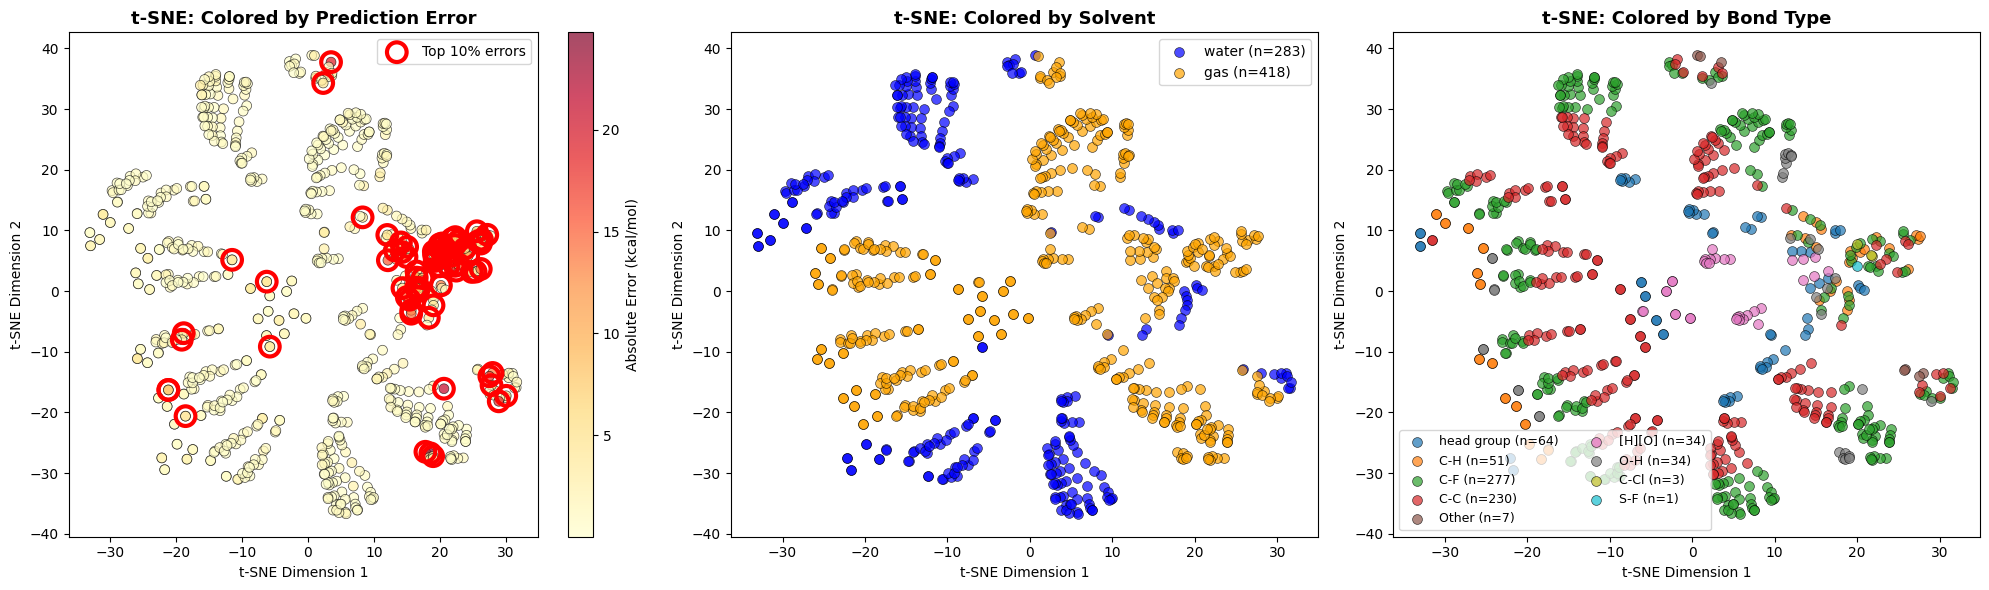

✓ t-SNE visualization saved as 'tsne_error_analysis.png'



In [8]:
# ============================================================================
# 6. t-SNE VISUALIZATION: HIGH-DIMENSIONAL FEATURE SPACE
# ============================================================================

print(f"\n{'='*80}")
print("t-SNE ANALYSIS: Visualizing Molecular Feature Space")
print(f"{'='*80}\n")
# Use the full feature set (fingerprints + solvent)
X_full = feature_sets['Full Features']
best_overall_model=XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
# Calculate errors if not already done
if 'Absolute_Error' not in df.columns:
    print("Calculating prediction errors from previous model...")
    # Use cross-validated predictions from your best model
    y_pred = cross_val_predict(
        best_overall_model,  
        X_full, 
        y, 
        cv=gkf, 
        groups=groups, 
        n_jobs=-1
    )
    df['Predicted_BDE'] = y_pred
    df['Residual'] = df['BDE_wB97X-V'] - df['Predicted_BDE']
    df['Absolute_Error'] = np.abs(df['Residual'])
    print(f"✓ Mean Absolute Error: {df['Absolute_Error'].mean():.3f} kcal/mol\n")

print("Running t-SNE dimensionality reduction...")
print("(This may take 1-2 minutes for samples...)")



# Run t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    n_iter=1000,
    verbose=0
)

X_tsne = tsne.fit_transform(X_full)

print("✓ t-SNE completed\n")

# Add t-SNE coordinates to dataframe
df['tsne_x'] = X_tsne[:, 0]
df['tsne_y'] = X_tsne[:, 1]

# Create simplified visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ============================================================================
# Plot 1: Color by error magnitude
# ============================================================================
scatter = axes[0].scatter(
    df['tsne_x'], df['tsne_y'], 
    c=df['Absolute_Error'], 
    cmap='YlOrRd',
    s=50, 
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)
axes[0].set_title('t-SNE: Colored by Prediction Error', fontsize=13, fontweight='bold')
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Absolute Error (kcal/mol)', fontsize=10)

# Highlight worst predictions
worst_mask = df['Absolute_Error'] > df['Absolute_Error'].quantile(0.9)
axes[0].scatter(
    df[worst_mask]['tsne_x'], 
    df[worst_mask]['tsne_y'],
    s=200,
    facecolors='none',
    edgecolors='red',
    linewidths=3,
    label='Top 10% errors'
)
axes[0].legend()

# ============================================================================
# Plot 2: Color by solvent
# ============================================================================
colors = {'water': 'blue', 'gas': 'orange'}
for solvent in df['solvent'].unique():
    mask = df['solvent'] == solvent
    axes[1].scatter(
        df[mask]['tsne_x'],
        df[mask]['tsne_y'],
        c=colors[solvent],
        label=f'{solvent} (n={mask.sum()})',
        s=50,
        alpha=0.7,
        edgecolor='black',
        linewidth=0.5
    )
axes[1].set_title('t-SNE: Colored by Solvent', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].legend()

# ============================================================================
# Plot 3: Identify bond types
# ============================================================================

def guess_bond_type(frag1_smiles, frag2_smiles):
    """Identify bond type from fragment SMILES"""
    head_groups = ['[S](=O)', '[H]O[C](=O)', 'O=[C][O-]', 'O=[S](=O)[O-]', 
                   '[H]O[S](=O)=O', '[H]O[C]=O']
    
    if '[F]' == frag1_smiles or '[F]' == frag2_smiles:
        if '[S]' in frag1_smiles or '[S]' in frag2_smiles:
            return 'S-F'
        if '[C]' in frag1_smiles or '[C]' in frag2_smiles:
            return 'C-F'
        else:
            return 'C-F Other'
    
    if '[C]' in frag1_smiles or '[C]' in frag2_smiles:
        if frag1_smiles in head_groups or frag2_smiles in head_groups:
            return 'head group'
        if '[C]' in frag1_smiles and '[C]' in frag2_smiles:
            return 'C-C'
        if frag1_smiles == '[H]' or frag2_smiles == '[H]':
            return 'C-H'
        if '[Cl]' in frag1_smiles or '[Cl]' in frag2_smiles:
            return 'C-Cl'
        if '[H][O]' in frag1_smiles or '[H][O]' in frag2_smiles:
            return '[H][O]'
        else:
            return 'Other'
    
    if '[H]' == frag1_smiles or '[H]' == frag2_smiles:
        if '[O]' in frag1_smiles or '[O]' in frag2_smiles:
            return 'O-H'
    
    if '[H][O]' in frag1_smiles or '[H][O]' in frag2_smiles:
        return '[H][O]'
    
    return 'Other 2'

df['Bond_Type'] = df.apply(lambda row: guess_bond_type(row['Frag1_SMILES'], row['Frag2_SMILES']), axis=1)


bond_types = df['Bond_Type'].unique()
colors_bonds = plt.cm.tab10(np.linspace(0, 1, len(bond_types)))

for i, bond_type in enumerate(bond_types):
    mask = df['Bond_Type'] == bond_type
    axes[2].scatter(
        df[mask]['tsne_x'],
        df[mask]['tsne_y'],
        c=[colors_bonds[i]],
        label=f'{bond_type} (n={mask.sum()})',
        s=50,
        alpha=0.7,
        edgecolor='black',
        linewidth=0.5
    )
axes[2].set_title('t-SNE: Colored by Bond Type', fontsize=13, fontweight='bold')
axes[2].set_xlabel('t-SNE Dimension 1')
axes[2].set_ylabel('t-SNE Dimension 2')
axes[2].legend(fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig('../Data/Figures/tsne_error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ t-SNE visualization saved as 'tsne_error_analysis.png'\n")
print("="*80)

In [15]:
#df[df["Bond_Type"]=='head group']
#df.head()
#pd.set_option('display.max_rows', 50)
#df[df["deprotonation"]==False]
# df.head()

In [16]:
# ============================================================================
# EXTRACT HIGH-ERROR CLUSTER (top-right region of t-SNE)
# ============================================================================
print(f"\n{'='*80}")
print("HIGH-ERROR CLUSTER EXTRACTION")
print(f"{'='*80}\n")

# Define the cluster region based on t-SNE coordinates
# You identified: D1 (x-axis) between 10-30, D2 (y-axis) between -10 to 10
cluster_mask = (
    (df['tsne_x'] >= 10) & (df['tsne_x'] <= 30) &
    (df['tsne_y'] >= -10) & (df['tsne_y'] <= 10)
)

# Also filter for top 10% errors
error_threshold = df['Absolute_Error'].quantile(0.90)
high_error_mask = df['Absolute_Error'] > error_threshold

# Combine: bonds in cluster AND high error
cluster_high_error = df[cluster_mask & high_error_mask].copy()

print(f"Cluster region: t-SNE D1 ∈ [10, 30], D2 ∈ [-10, 10]")
print(f"Error threshold (top 10%): {error_threshold:.3f} kcal/mol")
print(f"\nBonds in cluster region: {cluster_mask.sum()}")
print(f"High-error bonds in cluster: {len(cluster_high_error)}")
print(f"Percentage of all high errors: {len(cluster_high_error) / high_error_mask.sum() * 100:.1f}%\n")

# Sort by error magnitude
cluster_high_error = cluster_high_error.sort_values('Absolute_Error', ascending=False)

print("="*80)
print(f"ALL {len(cluster_high_error)} HIGH-ERROR BONDS FROM CLUSTER")
print("="*80)
print()

for i, (idx, row) in enumerate(cluster_high_error.iterrows(), 1):
    print(f"Bond {i} (Index {idx}):")
    print(f"  Bond Type:    {row['Bond_Type']}")
    print(f"  Solvent:      {row['solvent']}")
    print(f"  Parent:       {row['Parent_SMILES']}")
    print(f"  Fragment 1:   {row['Frag1_SMILES']}")
    print(f"  Fragment 2:   {row['Frag2_SMILES']}")
    print(f"  True BDE:     {row['BDE_wB97X-V']:.2f} kcal/mol")
    print(f"  Predicted:    {row['Predicted_BDE']:.2f} kcal/mol")
    print(f"  Residual:     {row['Residual']:+.2f} kcal/mol")  # Changed from Error
    print(f"  Abs Error:    {row['Absolute_Error']:.2f} kcal/mol")  # Changed formatting
    print(f"  t-SNE coords: ({row['tsne_x']:.2f}, {row['tsne_y']:.2f})")
    print()

# Summary statistics for this cluster
print("="*80)
print("CLUSTER SUMMARY")
print("="*80)

print(f"\nBond Type Distribution:")
for bond_type, count in cluster_high_error['Bond_Type'].value_counts().items():
    pct = count / len(cluster_high_error) * 100
    print(f"  {bond_type:<25} {count:>3} ({pct:>5.1f}%)")

print(f"\nSolvent Distribution:")
for solvent, count in cluster_high_error['solvent'].value_counts().items():
    pct = count / len(cluster_high_error) * 100
    print(f"  {solvent:<25} {count:>3} ({pct:>5.1f}%)")

print(f"\nBDE Statistics:")
print(f"  Mean:   {cluster_high_error['BDE_wB97X-V'].mean():.2f} kcal/mol")
print(f"  Std:    {cluster_high_error['BDE_wB97X-V'].std():.2f} kcal/mol")
print(f"  Range:  {cluster_high_error['BDE_wB97X-V'].min():.2f} - {cluster_high_error['BDE_wB97X-V'].max():.2f} kcal/mol")

print(f"\nError Statistics:")
print(f"  Mean:   {cluster_high_error['Absolute_Error'].mean():.2f} kcal/mol")
print(f"  Max:    {cluster_high_error['Absolute_Error'].max():.2f} kcal/mol")

print(f"\nUnique Parent Molecules: {cluster_high_error['Parent_SMILES'].nunique()}")
print("\n" + "="*80)


HIGH-ERROR CLUSTER EXTRACTION

Cluster region: t-SNE D1 ∈ [10, 30], D2 ∈ [-10, 10]
Error threshold (top 10%): 3.401 kcal/mol

Bonds in cluster region: 83
High-error bonds in cluster: 50
Percentage of all high errors: 71.4%

ALL 50 HIGH-ERROR BONDS FROM CLUSTER

Bond 1 (Index 668):
  Bond Type:    S-F
  Solvent:      gas
  Parent:       FS(F)(F)(F)(F)F
  Fragment 1:   [F]
  Fragment 2:   F[S](F)(F)(F)F
  True BDE:     104.13 kcal/mol
  Predicted:    123.82 kcal/mol
  Residual:     -19.69 kcal/mol
  Abs Error:    19.69 kcal/mol
  t-SNE coords: (19.94, 4.08)

Bond 2 (Index 669):
  Bond Type:    C-F
  Solvent:      gas
  Parent:       FC(F)(F)C(F)(F)F
  Fragment 1:   [F]
  Fragment 2:   F[C](F)C(F)(F)F
  True BDE:     126.05 kcal/mol
  Predicted:    107.98 kcal/mol
  Residual:     +18.07 kcal/mol
  Abs Error:    18.07 kcal/mol
  t-SNE coords: (22.49, 3.37)

Bond 3 (Index 290):
  Bond Type:    C-F
  Solvent:      gas
  Parent:       FC(F)(F)F
  Fragment 1:   [F]
  Fragment 2:   F[C](F)F
  

## Error Analysis: t-SNE Clustering Results

Analysis of the high-error cluster (t-SNE region: D1 ∈ [10, 30], D2 ∈ [-10, 10]) reveals that the model struggles most with:

1. **C-F bonds in fluorinated alkenes and alkanes** - These represent a significant fraction of high-error predictions
2. **C-H bonds** - Also overrepresented in the error cluster

These bond types appear to form a distinct chemical subspace in the feature representation that the current training data does not adequately cover. This suggests the model has learned general PFAS patterns well but lacks sufficient examples of these specific bond environments.

**Implication for future work:** Expanding the database with additional fluorinated alkenes, alkanes, and molecules with C-H bonds will likely improve model performance in these underrepresented regions of chemical space. Target molecules should prioritize structures similar to those in the identified error cluster.

# Hyperparameter tuning for XGBoost
A quick parameter search was done here. Final model will do a long search.
Final optimized statistics:
 MAE:  1.299 ± 0.160 kcal/mol
  RMSE: 3.119 ± 0.350 kcal/mol
  R²:   0.957 ± 0.009

In [17]:
# ============================================================================
# HYPERPARAMETER TUNING: XGBoost Optimization
# ============================================================================

print("="*80)
print("XGBOOST HYPERPARAMETER TUNING")
print("="*80)

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import time

# FIRST: Store the original XGBoost performance for comparison
original_xgboost_mae = 1.582   # Your original result from model comparison
original_xgboost_std = 0.163

print(f"Baseline to beat: {original_xgboost_mae:.3f} ± {original_xgboost_std:.3f} kcal/mol")
print(f"(Original XGBoost with default hyperparameters)\n")

# ============================================================================
# CHOOSE TUNING MODE
# ============================================================================

TUNING_MODE = "long"  # Change to "long" for comprehensive search

if TUNING_MODE == "short":
    print("Running QUICK hyperparameter search (~2-3 minutes)...\n")
    
    param_grid = {
        'n_estimators': [50, 100, 200],        # Added 50 - sometimes helps with small data
        'max_depth': [3, 4, 6],                 # Reduced max depth to avoid overfitting
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 1.0],          # Added 0.7 for regularization
        'colsample_bytree': [0.7, 0.8, 1.0],
        'min_child_weight': [1, 3, 5],         # Higher values prevent overfitting
        'gamma': [0, 0.1]
    }
    n_iter = 30
    
elif TUNING_MODE == "long":
    print("Running COMPREHENSIVE hyperparameter search (~10-15 minutes)...\n")
    
    param_grid = {
        'n_estimators': [50, 100, 200, 300],   # 500 probably overkill for 700 points
        'max_depth': [2, 3, 4, 5, 6, 8],       # Added shallower trees (2, 5)
        'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
        'min_child_weight': [1, 3, 5, 10],     # Higher values for small datasets
        'gamma': [0, 0.05, 0.1, 0.2, 0.5],     # Added 0.5 for more regularization
        'reg_alpha': [0, 0.01, 0.1, 1, 10],    # L1 regularization important for small data
        'reg_lambda': [1, 10, 50, 100]         # L2 regularization
    }
    n_iter = 100

else:
    raise ValueError("TUNING_MODE must be 'short' or 'long'")

print(f"Parameter grid size: {np.prod([len(v) for v in param_grid.values()]):,} total combinations")
print(f"Sampling {n_iter} combinations with 5-fold CV = {n_iter * 5:,} model fits\n")

# ============================================================================
# RUN HYPERPARAMETER SEARCH
# ============================================================================

base_model = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=n_iter,
    scoring='neg_mean_absolute_error',
    cv=gkf,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
random_search.fit(X_full, y, groups=groups)
elapsed_time = time.time() - start_time

print(f"\n✓ Hyperparameter search completed in {elapsed_time/60:.1f} minutes")

# ============================================================================
# RESULTS
# ============================================================================

print("\n" + "="*80)
print("BEST HYPERPARAMETERS FOUND")
print("="*80)

best_params = random_search.best_params_
best_score = -random_search.best_score_  # Negative because sklearn uses neg_MAE

print(f"\nBest MAE from RandomizedSearchCV: {best_score:.3f} kcal/mol")
print(f"Original default MAE: {original_xgboost_mae:.3f} kcal/mol")
improvement = original_xgboost_mae - best_score
improvement_pct = (improvement / original_xgboost_mae) * 100

if improvement > 0:
    print(f"Improvement: {improvement:.3f} kcal/mol ({improvement_pct:.1f}% better) ✓")
else:
    print(f"Change: {improvement:+.3f} kcal/mol ({improvement_pct:+.1f}%) - tuning didn't help much")

print("\nOptimized hyperparameters:")
print("-" * 40)
for param, value in sorted(best_params.items()):
    print(f"  {param:<20s}: {value}")

# Rest of your code continues the same...

XGBOOST HYPERPARAMETER TUNING
Baseline to beat: 1.582 ± 0.163 kcal/mol
(Original XGBoost with default hyperparameters)

Running COMPREHENSIVE hyperparameter search (~10-15 minutes)...

Parameter grid size: 1,200,000 total combinations
Sampling 100 combinations with 5-fold CV = 500 model fits

Fitting 5 folds for each of 100 candidates, totalling 500 fits

✓ Hyperparameter search completed in 4.6 minutes

BEST HYPERPARAMETERS FOUND

Best MAE from RandomizedSearchCV: 1.442 kcal/mol
Original default MAE: 1.582 kcal/mol
Improvement: 0.140 kcal/mol (8.9% better) ✓

Optimized hyperparameters:
----------------------------------------
  colsample_bytree    : 0.8
  gamma               : 0.5
  learning_rate       : 0.1
  max_depth           : 6
  min_child_weight    : 3
  n_estimators        : 300
  reg_alpha           : 1
  reg_lambda          : 1
  subsample           : 0.7


# Save Model

In [9]:
# ============================================================================
# FULL EVALUATION WITH BEST MODEL (TUNED HYPERPARAMETERS)
# ============================================================================

print("\n" + "="*80)
print("EVALUATING TUNED MODEL WITH PROPER CV")
print("="*80)

# Create model with your tuned hyperparameters
tuned_model = XGBRegressor(
    colsample_bytree=0.8,
    gamma=0.5,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=3,
    n_estimators=300,
    reg_alpha=1,
    reg_lambda=1,
    subsample=0.7,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

# Proper cross-validation evaluation
maes = []
rmses = []
r2s = []

print("\nRunning 5-fold cross-validation...")

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_full, y, groups), 1):
    X_train, X_test = X_full[train_idx], X_full[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    tuned_model.fit(X_train, y_train)
    y_pred = tuned_model.predict(X_test)
    
    fold_mae = mean_absolute_error(y_test, y_pred)
    fold_rmse = root_mean_squared_error(y_test, y_pred)
    fold_r2 = r2_score(y_test, y_pred)
    
    maes.append(fold_mae)
    rmses.append(fold_rmse)
    r2s.append(fold_r2)
    
    print(f"  Fold {fold}: MAE = {fold_mae:.3f}, RMSE = {fold_rmse:.3f}, R² = {fold_r2:.3f}")

print("\n" + "="*80)
print("TUNED XGBOOST PERFORMANCE")
print("="*80)
print(f"\n  MAE:  {np.mean(maes):.3f} ± {np.std(maes):.3f} kcal/mol")
print(f"  RMSE: {np.mean(rmses):.3f} ± {np.std(rmses):.3f} kcal/mol")
print(f"  R²:   {np.mean(r2s):.3f} ± {np.std(r2s):.3f}")

print(f"\n📊 Comparison to default:")
print(f"  Default MAE:  1.622 ± 0.275 kcal/mol")
print(f"  Tuned MAE:    {np.mean(maes):.3f} ± {np.std(maes):.3f} kcal/mol")
improvement = 1.622 - np.mean(maes)
print(f"  Improvement:  {improvement:+.3f} kcal/mol ({improvement/1.767*100:.1f}%)")

print("="*80)


EVALUATING TUNED MODEL WITH PROPER CV

Running 5-fold cross-validation...
  Fold 1: MAE = 1.456, RMSE = 3.131, R² = 0.958
  Fold 2: MAE = 1.545, RMSE = 3.325, R² = 0.951
  Fold 3: MAE = 1.284, RMSE = 3.120, R² = 0.957
  Fold 4: MAE = 1.600, RMSE = 3.809, R² = 0.939
  Fold 5: MAE = 1.323, RMSE = 2.855, R² = 0.961

TUNED XGBOOST PERFORMANCE

  MAE:  1.442 ± 0.122 kcal/mol
  RMSE: 3.248 ± 0.318 kcal/mol
  R²:   0.953 ± 0.008

📊 Comparison to default:
  Default MAE:  1.622 ± 0.275 kcal/mol
  Tuned MAE:    1.442 ± 0.122 kcal/mol
  Improvement:  +0.180 kcal/mol (10.2%)


NameError: name 'df_full' is not defined

In [11]:
# ============================================================================
# FULL EVALUATION WITH BEST MODEL (TUNED HYPERPARAMETERS)
# ============================================================================
print("\n" + "="*80)
print("EVALUATING TUNED MODEL WITH PROPER CV")
print("="*80)

tuned_model = XGBRegressor(
    colsample_bytree=0.8,
    gamma=0.5,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=3,
    n_estimators=300,
    reg_alpha=1,
    reg_lambda=1,
    subsample=0.7,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

maes, rmses, r2s = [], [], []

# ── NEW: collectors for confidence ────────────────────────────────────────────
oof_residuals = []   # |y_true - y_pred| for each OOF sample
oof_y_true    = []   # sanity check / plotting later
oof_y_pred    = []
# ─────────────────────────────────────────────────────────────────────────────

print("\nRunning 5-fold cross-validation...")
for fold, (train_idx, test_idx) in enumerate(gkf.split(X_full, y, groups), 1):
    X_train, X_test = X_full[train_idx], X_full[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    tuned_model.fit(X_train, y_train)
    y_pred = tuned_model.predict(X_test)

    fold_mae  = mean_absolute_error(y_test, y_pred)
    fold_rmse = root_mean_squared_error(y_test, y_pred)
    fold_r2   = r2_score(y_test, y_pred)

    maes.append(fold_mae)
    rmses.append(fold_rmse)
    r2s.append(fold_r2)

    # ── NEW: collect OOF residuals ─────────────────────────────────────────
    oof_residuals.extend(np.abs(y_test - y_pred))
    oof_y_true.extend(y_test)
    oof_y_pred.extend(y_pred)
    # ───────────────────────────────────────────────────────────────────────

    print(f"  Fold {fold}: MAE = {fold_mae:.3f}, RMSE = {fold_rmse:.3f}, R² = {fold_r2:.3f}")

oof_residuals = np.array(oof_residuals)
oof_y_true    = np.array(oof_y_true)
oof_y_pred    = np.array(oof_y_pred)

# ============================================================================
# CONFORMAL PREDICTION QUANTILES
# ============================================================================
print("\n" + "="*80)
print("CONFORMAL PREDICTION INTERVALS")
print("="*80)

for coverage in [0.80, 0.90, 0.95]:
    q = np.quantile(oof_residuals, coverage)
    print(f"  {int(coverage*100)}% coverage interval: ±{q:.3f} kcal/mol")

# Use 90% as your production threshold
conformal_quantile_90 = np.quantile(oof_residuals, 0.90)

# Quick sanity check — empirical coverage should match nominal
within_90 = np.mean(oof_residuals <= conformal_quantile_90)
print(f"\n  Empirical coverage check: {within_90*100:.1f}% (should be ~90%)")

# ============================================================================
# APPLICABILITY DOMAIN — TANIMOTO TO TRAINING SET
# ============================================================================
print("\n" + "="*80)
print("APPLICABILITY DOMAIN THRESHOLD")
print("="*80)

# X_full is a numpy bit array — convert rows to RDKit fingerprint objects
# so we can use Tanimoto similarity
from rdkit.DataStructs import CreateFromBitString
from rdkit import DataStructs

def numpy_to_rdkit_fp(row):
    """Convert a numpy 0/1 array to an RDKit ExplicitBitVect."""
    return CreateFromBitString("".join(row.astype(int).astype(str)))

print("  Converting fingerprints...")
# X_full = [2048 Morgan bits | 1 solvent col] — strip solvent before Tanimoto
X_morgan = X_full[:, :-1]
training_fps_rdkit = [numpy_to_rdkit_fp(X_morgan[i]) for i in range(len(X_morgan))]

# For each sample, compute mean Tanimoto to its 5 nearest neighbors
# (excluding itself). This gives a baseline "how similar is this to its
# neighbors inside the training set" distribution.
print("  Computing internal similarities (this may take ~30s for <1k samples)...")
K = 5
internal_sims = []
for i, fp in enumerate(training_fps_rdkit):
    sims = DataStructs.BulkTanimotoSimilarity(fp, 
               [training_fps_rdkit[j] for j in range(len(training_fps_rdkit)) if j != i])
    top_k = sorted(sims, reverse=True)[:K]
    internal_sims.append(np.mean(top_k))

internal_sims = np.array(internal_sims)

# 5th percentile = boundary of the training distribution
# Queries below this are "outside" the domain
domain_threshold = np.percentile(internal_sims, 5)
print(f"  Domain threshold (5th percentile): {domain_threshold:.3f}")
print(f"  Median internal similarity:        {np.median(internal_sims):.3f}")

# ============================================================================
# SAVE CONFIDENCE ARTIFACTS
# ============================================================================
import pickle, json

confidence_metadata = {
    'conformal_quantile_80': float(np.quantile(oof_residuals, 0.80)),
    'conformal_quantile_90': float(conformal_quantile_90),
    'conformal_quantile_95': float(np.quantile(oof_residuals, 0.95)),
    'domain_threshold':      float(domain_threshold),
    'n_calibration_samples': int(len(oof_residuals)),
    'empirical_coverage_90': float(within_90),
    'residual_mean':         float(oof_residuals.mean()),
    'residual_std':          float(oof_residuals.std()),
}

with open('confidence_metadata.json', 'w') as f:
    json.dump(confidence_metadata, f, indent=2)
print("\n✓ Confidence metadata saved as 'confidence_metadata.json'")

with open('training_fps.pkl', 'wb') as f:
    pickle.dump(training_fps_rdkit, f)
print("✓ Training fingerprints saved as 'training_fps.pkl'")

# ============================================================================
# PERFORMANCE SUMMARY (unchanged)
# ============================================================================
print("\n" + "="*80)
print("TUNED XGBOOST PERFORMANCE")
print("="*80)
print(f"\n  MAE:  {np.mean(maes):.3f} ± {np.std(maes):.3f} kcal/mol")
print(f"  RMSE: {np.mean(rmses):.3f} ± {np.std(rmses):.3f} kcal/mol")
print(f"  R²:   {np.mean(r2s):.3f} ± {np.std(r2s):.3f}")
improvement = 1.622 - np.mean(maes)
print(f"  Improvement over default: {improvement:+.3f} kcal/mol ({improvement/1.767*100:.1f}%)")
print("="*80)


EVALUATING TUNED MODEL WITH PROPER CV

Running 5-fold cross-validation...
  Fold 1: MAE = 1.456, RMSE = 3.131, R² = 0.958
  Fold 2: MAE = 1.545, RMSE = 3.325, R² = 0.951
  Fold 3: MAE = 1.284, RMSE = 3.120, R² = 0.957
  Fold 4: MAE = 1.600, RMSE = 3.809, R² = 0.939
  Fold 5: MAE = 1.323, RMSE = 2.855, R² = 0.961

CONFORMAL PREDICTION INTERVALS
  80% coverage interval: ±1.458 kcal/mol
  90% coverage interval: ±2.713 kcal/mol
  95% coverage interval: ±5.966 kcal/mol

  Empirical coverage check: 90.0% (should be ~90%)

APPLICABILITY DOMAIN THRESHOLD
  Converting fingerprints...
  Computing internal similarities (this may take ~30s for <1k samples)...
  Domain threshold (5th percentile): 0.438
  Median internal similarity:        0.766

✓ Confidence metadata saved as 'confidence_metadata.json'
✓ Training fingerprints saved as 'training_fps.pkl'

TUNED XGBOOST PERFORMANCE

  MAE:  1.442 ± 0.122 kcal/mol
  RMSE: 3.248 ± 0.318 kcal/mol
  R²:   0.953 ± 0.008
  Improvement over default: +0.180

In [12]:
# ============================================================================
# TRAINING FINAL MODEL ON FULL DATASET
# ============================================================================
print("\n" + "="*80)
print("TRAINING FINAL MODEL ON FULL DATASET")
print("="*80)

final_model = XGBRegressor(
    colsample_bytree=0.8,
    gamma=0.5,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=3,
    n_estimators=300,
    reg_alpha=1,
    reg_lambda=1,
    subsample=0.7,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
print("\nTraining on full dataset...")
final_model.fit(X_full, y)

# ============================================================================
# SAVE ALL COMPONENTS
# ============================================================================
import pickle, json
from datetime import date

# 1. Model
with open('xgboost_bde_model_optimized.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("\n✓ Model saved as 'xgboost_bde_model_optimized.pkl'")

# 2. Solvent encoder
with open('solvent_encoder.pkl', 'wb') as f:
    pickle.dump(enc, f)
print("✓ Solvent encoder saved as 'solvent_encoder.pkl'")

# 3. Training fingerprints for applicability domain
#    (generated in CV block above — Morgan bits only, solvent column stripped)
with open('training_fps.pkl', 'wb') as f:
    pickle.dump(training_fps_rdkit, f)
print("✓ Training fingerprints saved as 'training_fps.pkl'")

# 4. Model metadata (performance + confidence thresholds combined)
model_metadata = {
    'model': 'XGBoost',
    'performance': {
        'mae':      float(np.mean(maes)),
        'mae_std':  float(np.std(maes)),
        'rmse':     float(np.mean(rmses)),
        'rmse_std': float(np.std(rmses)),
        'r2':       float(np.mean(r2s)),
        'r2_std':   float(np.std(r2s)),
    },
    'confidence': {
        'conformal_quantile_80': float(np.quantile(oof_residuals, 0.80)),
        'conformal_quantile_90': float(np.quantile(oof_residuals, 0.90)),
        'conformal_quantile_95': float(np.quantile(oof_residuals, 0.95)),
        'empirical_coverage_90': float(np.mean(oof_residuals <= np.quantile(oof_residuals, 0.90))),
        'n_calibration_samples': int(len(oof_residuals)),
        'domain_threshold':      float(domain_threshold),
        'domain_k_neighbors':    5,
    },
    'hyperparameters': {
        'colsample_bytree': 0.8,
        'gamma':            0.5,
        'learning_rate':    0.1,
        'max_depth':        6,
        'min_child_weight': 3,
        'n_estimators':     300,
        'reg_alpha':        1,
        'reg_lambda':       1,
        'subsample':        0.7,
    },
    'training_info': {
        'n_samples':      int(len(X_full)),
        'n_features':     int(X_full.shape[1]),
        'feature_type':   'Morgan fingerprints (2048 bits, radius=2) + 1 solvent feature',
        'solvent_options': list(enc.categories_[0]),
        'cv_strategy':    '5-fold grouped by parent PFAS',
    },
    'date_trained': str(date.today()),
}

with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)
print("✓ Model metadata saved as 'model_metadata.json'")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*80)
print("PRODUCTION MODEL READY")
print("="*80)
print(f"\n📦 Saved files:")
print(f"   - xgboost_bde_model_optimized.pkl  (trained model)")
print(f"   - solvent_encoder.pkl              (OneHotEncoder for solvent)")
print(f"   - training_fps.pkl                 (Morgan fps for domain check)")
print(f"   - model_metadata.json              (performance, confidence & hyperparameters)")
print(f"\n🎯 Performance:")
print(f"   MAE:  {np.mean(maes):.3f} ± {np.std(maes):.3f} kcal/mol")
print(f"   RMSE: {np.mean(rmses):.3f} ± {np.std(rmses):.3f} kcal/mol")
print(f"   R²:   {np.mean(r2s):.3f} ± {np.std(r2s):.3f}")
print(f"\n🎯 Confidence:")
print(f"   80% interval: ±{np.quantile(oof_residuals, 0.80):.3f} kcal/mol")
print(f"   90% interval: ±{np.quantile(oof_residuals, 0.90):.3f} kcal/mol")
print(f"   Domain threshold (Tanimoto): {domain_threshold:.3f}")
print("\n✅ Model ready for deployment!")
print("="*80)


TRAINING FINAL MODEL ON FULL DATASET

Training on full dataset...

✓ Model saved as 'xgboost_bde_model_optimized.pkl'
✓ Solvent encoder saved as 'solvent_encoder.pkl'
✓ Training fingerprints saved as 'training_fps.pkl'
✓ Model metadata saved as 'model_metadata.json'

PRODUCTION MODEL READY

📦 Saved files:
   - xgboost_bde_model_optimized.pkl  (trained model)
   - solvent_encoder.pkl              (OneHotEncoder for solvent)
   - training_fps.pkl                 (Morgan fps for domain check)
   - model_metadata.json              (performance, confidence & hyperparameters)

🎯 Performance:
   MAE:  1.442 ± 0.122 kcal/mol
   RMSE: 3.248 ± 0.318 kcal/mol
   R²:   0.953 ± 0.008

🎯 Confidence:
   80% interval: ±1.458 kcal/mol
   90% interval: ±2.713 kcal/mol
   Domain threshold (Tanimoto): 0.438

✅ Model ready for deployment!
